In [ ]:
!pip install torch-geometric


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 18.3 MB/s eta 0:00:00


In [ ]:
# Basic libraries
import json
import random
import networkx as nx
import matplotlib.pyplot as plt
import numpy as np


# PyTorch
import torch
import torch.nn.functional as F

# PyTorch Geometric
from torch_geometric.data import Data, DataLoader
from torch_geometric.nn import GATConv


In [ ]:
import os
print(os.getcwd())
print(os.listdir())

/content
['.config', 'sample_data']


In [ ]:
from google.colab import files
uploaded = files.upload()

Saving domain.json to domain.json


In [ ]:
# Load domain knowledge JSON
with open("domain.json", "r") as f:
    knowledge = json.load(f)

# Verify structure
print("Top-level keys:", knowledge.keys())
print("Diseases:", list(knowledge["diseases"].keys()))

Top-level keys: dict_keys(['domain', 'source_text', 'diseases'])
Diseases: ['Vidradhi', 'Gulma', 'Udara']


In [ ]:
# Building Knowledge Graph
import networkx as nx
import random

G = nx.Graph()

all_symptoms = set()
all_types = []

for disease, details in knowledge["diseases"].items():
    for dtype, info in details["types"].items():
        symptoms = info["symptoms"]

        # disease node
        G.add_node(dtype, node_type="disease")
        all_types.append(dtype)

        for symptom in symptoms:
            # symptom node
            G.add_node(symptom, node_type="symptom")
            freq = symptoms.count(symptom)
            G.add_edge(dtype, symptom, weight=1.0 / freq)  # add edge weight
            all_symptoms.add(symptom)

print("Total disease types:", len(all_types))
print("Total symptoms:", len(all_symptoms))


Total disease types: 14
Total symptoms: 93


In [ ]:
label_map = {d: i for i, d in enumerate(sorted(all_types))}
inv_label_map = {v: k for k, v in label_map.items()}
num_classes = len(label_map)

print("Classes:", num_classes)

Classes: 14


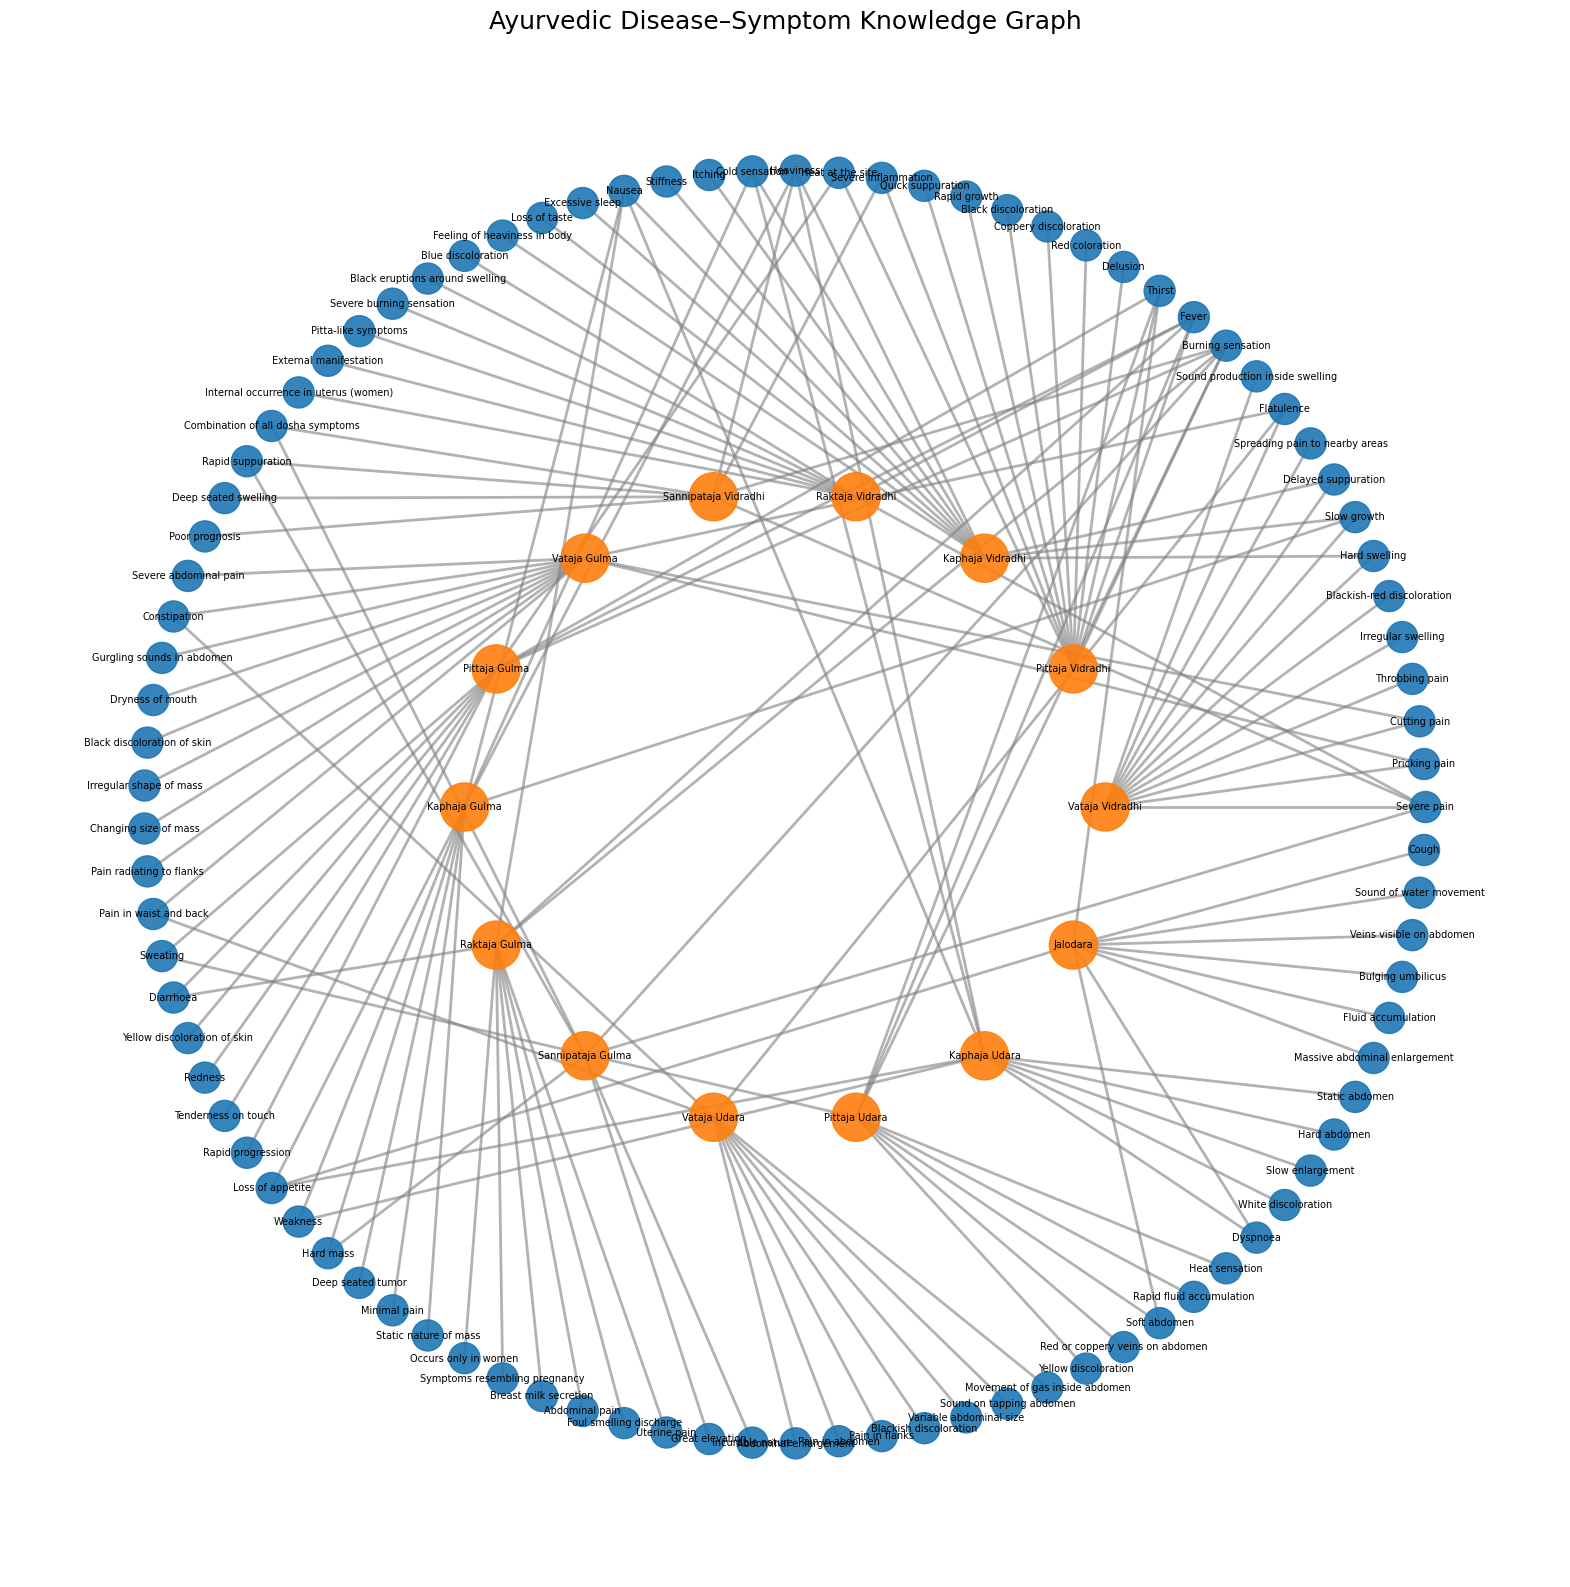

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import networkx as nx

plt.figure(figsize=(20, 20))

pos = {}

# Radii for concentric circles
R_DISEASE = 3
R_TYPE = 6
R_SYMPTOM = 12

# Collect nodes
diseases = list(knowledge["diseases"].keys())
types = []
symptoms = []

for disease, details in knowledge["diseases"].items():
    for dtype, info in details["types"].items():
        types.append(dtype)
        for s in info["symptoms"]:
            if s not in symptoms:
                symptoms.append(s)

# ---- Disease groups (small circle at center) ----
angle_step = 2 * np.pi / len(diseases)
for i, disease in enumerate(diseases):
    angle = i * angle_step
    pos[disease] = (R_DISEASE * np.cos(angle), R_DISEASE * np.sin(angle))

# ---- Disease types (middle circle) ----
angle_step = 2 * np.pi / len(types)
for i, dtype in enumerate(types):
    angle = i * angle_step
    pos[dtype] = (R_TYPE * np.cos(angle), R_TYPE * np.sin(angle))

# ---- Symptoms (outer circle) ----
angle_step = 2 * np.pi / len(symptoms)
for i, symptom in enumerate(symptoms):
    angle = i * angle_step
    pos[symptom] = (R_SYMPTOM * np.cos(angle), R_SYMPTOM * np.sin(angle))

# Node colors & sizes
node_colors, node_sizes = [], []
for node in G.nodes():
    if node in diseases:
        node_colors.append("#d62728")  # RED → disease group
        node_sizes.append(2000)
    elif node in types:
        node_colors.append("#ff7f0e")  # ORANGE → disease type
        node_sizes.append(1200)
    else:
        node_colors.append("#1f77b4")  # BLUE → symptom
        node_sizes.append(500)

# Edge weights for visualization
weights = [G[u][v].get("weight", 1.0) for u, v in G.edges()]

# ---- DRAW GRAPH ----
nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=7)
nx.draw_networkx_edges(G, pos, width=[w*2 for w in weights], edge_color="gray", alpha=0.6)

plt.title("Ayurvedic Disease–Symptom Knowledge Graph", fontsize=18)
plt.axis("off")
plt.show()


In [ ]:
def create_patient_graph(disease_type, symptom_list):
    temp_graph = nx.Graph()
    temp_graph.add_node("patient_case", node_type="patient")

    # ---- positive symptoms (true ones) ----
    k = max(3, int(0.7 * len(symptom_list)))
    pos_symptoms = random.sample(symptom_list, k=k)

    for s in pos_symptoms:
        if random.random() < 0.9:
            temp_graph.add_node(s, node_type="symptom")
            temp_graph.add_edge("patient_case", s, weight=2.0)  # stronger weight

    # ---- negative symptoms (noise) ----
    other_symptoms = list(all_symptoms - set(symptom_list))
    noise_k = random.randint(1, 3)

    if len(other_symptoms) > 0:
        noise_samples = random.sample(
            other_symptoms,
            k=min(noise_k, len(other_symptoms))
        )
        for s in noise_samples:
            temp_graph.add_node(s, node_type="symptom")
            temp_graph.add_edge("patient_case", s, weight=0.5)  # weaker weight

    return temp_graph


In [ ]:
symptom_to_id = {symptom: i for i, symptom in enumerate(all_symptoms)}
print("Symptom to ID mapping created.")

Symptom to ID mapping created.


In [ ]:
from torch_geometric.data import Data
import torch

def nx_to_pyg(graph, label):
    nodes = list(graph.nodes())
    idx = {node: i for i, node in enumerate(nodes)}

    # -------- edges --------
    edges = []
    edge_weights = []
    for u, v in graph.edges():
        w = graph[u][v].get("weight", 1.0)  # default weight = 1.0
        edges.append([idx[u], idx[v]])
        edge_weights.append(w)
        edges.append([idx[v], idx[u]])
        edge_weights.append(w)

    edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()
    edge_attr = torch.tensor(edge_weights, dtype=torch.float).unsqueeze(1)

    # -------- node features --------
    x = []
    for node in nodes:
        node_type = graph.nodes[node].get("node_type")

        # base type encoding
        if node_type == "disease":
            base = [1, 0, 0]
        elif node_type == "symptom":
            base = [0, 1, 0]
        else:  # patient
            base = [0, 0, 1]

        # unique hash feature
        hash_val = (hash(node) % 1000) / 1000.0
        x.append(base + [hash_val])  # now 4 features

    x = torch.tensor(x, dtype=torch.float)
    y = torch.tensor([label], dtype=torch.long)

    return Data(x=x, edge_index=edge_index, edge_attr=edge_attr, y=y)


In [ ]:
#....... DataSet Creation..........#
dataset = []

TARGET_SAMPLES = 21000

# collect all disease types and their symptoms
types_list = []
for disease, details in knowledge["diseases"].items():
    for dtype, info in details["types"].items():
        types_list.append((dtype, info["symptoms"]))

# how many samples per type
samples_per_type = TARGET_SAMPLES // len(types_list)

# generate patient graphs and convert to PyG
for dtype, symptoms in types_list:
    for _ in range(samples_per_type):
        pg = create_patient_graph(dtype, symptoms)              # patient case graph
        pyg_graph = nx_to_pyg(pg, label_map[dtype])             # convert to PyG Data (with edge_attr)
        dataset.append(pyg_graph)

print("Total samples:", len(dataset))


Total samples: 21000


In [ ]:
print("Num classes:", len(label_map))
print("Sample graph:", dataset[0])
print("Node feature shape:", dataset[0].x.shape)

Num classes: 14
Sample graph: Data(x=[9, 4], edge_index=[2, 16], edge_attr=[16, 1], y=[1])
Node feature shape: torch.Size([9, 4])


In [ ]:
from collections import Counter

labels = [data.y.item() for data in dataset]   # get labels from dataset
counts = Counter(labels)

print("Classes with samples:", sorted(counts.keys()))
print("Expected classes:", list(range(len(label_map))))

Classes with samples: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
Expected classes: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]


In [ ]:
from collections import Counter
import torch

# make sure device exists
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# compute class weights
labels = [data.y.item() for data in dataset]
counts = Counter(labels)

total = len(labels)
weights = []

for i in range(len(label_map)):
    weights.append(total / counts[i])

class_weights = torch.tensor(weights, dtype=torch.float).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

In [ ]:
####......Training and testing the dataset.........####
from sklearn.model_selection import train_test_split

train_data, test_data = train_test_split(
    dataset,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training samples:", len(train_data))
print("Testing samples:", len(test_data))

Training samples: 16800
Testing samples: 4200


In [ ]:
# Creating the datloader
from torch_geometric.loader import DataLoader  # ✅ CORRECT

train_loader = DataLoader(train_data, batch_size=64, shuffle=True)
test_loader = DataLoader(test_data, batch_size=64)

In [ ]:
import torch
import torch.nn.functional as F
from torch.nn import Linear
from torch_geometric.nn import GATConv, global_mean_pool


In [ ]:
# Check if edge_attr exists in your dataset
sample = dataset[0]  # take the first graph

print("Has edge_attr:", hasattr(sample, 'edge_attr'))
if hasattr(sample, 'edge_attr'):
    print("Edge attr shape:", sample.edge_attr.shape)
    print("First few edge attrs:", sample.edge_attr[:5])
else:
    print("No edge attributes found in this dataset.")


Has edge_attr: True
Edge attr shape: torch.Size([16, 1])
First few edge attrs: tensor([[2.],
        [2.],
        [2.],
        [2.],
        [2.]])


In [ ]:
from torch_geometric.nn import GATConv, global_mean_pool
import torch.nn.functional as F
import torch

class GATSimple(torch.nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        # First GAT layer: 4 input node features → 128 hidden, 4 heads
        self.gat1 = GATConv(4, 128, heads=4, concat=True)
        # Second GAT layer: 128*4 → 128
        self.gat2 = GATConv(128 * 4, 128)
        # Third GAT layer: 128 → 128
        self.gat3 = GATConv(128, 128)
        # Final linear classifier
        self.lin = torch.nn.Linear(128, num_classes)

    def forward(self, data):
        x, edge_index, batch = data.x, data.edge_index, data.batch
        edge_attr = data.edge_attr  # ✅ now included

        # Pass edge_attr into each GATConv
        x = F.relu(self.gat1(x, edge_index, edge_attr=edge_attr))
        x = F.relu(self.gat2(x, edge_index, edge_attr=edge_attr))
        x = F.relu(self.gat3(x, edge_index, edge_attr=edge_attr))

        # ⭐ CRITICAL FOR GRAPH CLASSIFICATION
        x = global_mean_pool(x, batch)

        x = self.lin(x)
        return x


In [ ]:
# Check for GPU and set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


In [ ]:
# Re-initializing the model and moving to device
# Re-initializing the model and moving to device

# number of classes
num_classes = len(label_map)

model = GATSimple(num_classes).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4) #l2 regularization


# ⭐ USE CLASS WEIGHTS (IMPORTANT)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights)

print(model)

GATSimple(
  (gat1): GATConv(4, 128, heads=4)
  (gat2): GATConv(512, 128, heads=1)
  (gat3): GATConv(128, 128, heads=1)
  (lin): Linear(in_features=128, out_features=14, bias=True)
)


In [ ]:
#Train function - Modified for GPU
def train():
    model.train()
    total_loss = 0.0

    for data in train_loader:
        data = data.to(device)  # move batch to GPU/CPU

        optimizer.zero_grad()

        out = model(data)              # forward
        loss = criterion(out, data.y)  # compute loss

        loss.backward()                # backprop
        optimizer.step()               # update weights

        total_loss += loss.item()

    return total_loss / len(train_loader)

In [ ]:
#Test function - Modified for GPU
@torch.no_grad()
def test(loader):
    model.eval()
    correct = 0
    total = 0

    for data in loader:
        data = data.to(device)  # ⭐ VERY IMPORTANT
        out = model(data)
        pred = out.argmax(dim=1)

        correct += (pred == data.y).sum().item()
        total += data.y.size(0)

    return correct / total

In [ ]:
#Train Model#
# Train Model
train_acc_list = []
test_acc_list = []

for epoch in range(1, 151):
    loss = train()
    train_acc = test(train_loader)
    test_acc = test(test_loader)

    train_acc_list.append(train_acc)
    test_acc_list.append(test_acc)

    print(f"Epoch {epoch:03d}, "
          f"Loss: {loss:.4f}, "
          f"Train Acc: {train_acc:.4f}, "
          f"Test Acc: {test_acc:.4f}")


Epoch 001, Loss: 2.4348, Train Acc: 0.1800, Test Acc: 0.1714
Epoch 002, Loss: 2.2974, Train Acc: 0.1957, Test Acc: 0.1924
Epoch 003, Loss: 2.2491, Train Acc: 0.2049, Test Acc: 0.1850
Epoch 004, Loss: 2.2006, Train Acc: 0.2466, Test Acc: 0.2350
Epoch 005, Loss: 2.0963, Train Acc: 0.2946, Test Acc: 0.2890
Epoch 006, Loss: 1.9439, Train Acc: 0.3376, Test Acc: 0.3338
Epoch 007, Loss: 1.8388, Train Acc: 0.3868, Test Acc: 0.3740
Epoch 008, Loss: 1.7143, Train Acc: 0.4354, Test Acc: 0.4255
Epoch 009, Loss: 1.5866, Train Acc: 0.4897, Test Acc: 0.4798
Epoch 010, Loss: 1.4772, Train Acc: 0.4940, Test Acc: 0.4755
Epoch 011, Loss: 1.4171, Train Acc: 0.5335, Test Acc: 0.5169
Epoch 012, Loss: 1.3506, Train Acc: 0.5613, Test Acc: 0.5548
Epoch 013, Loss: 1.2853, Train Acc: 0.5541, Test Acc: 0.5450
Epoch 014, Loss: 1.2258, Train Acc: 0.5942, Test Acc: 0.5848
Epoch 015, Loss: 1.1745, Train Acc: 0.6254, Test Acc: 0.6155
Epoch 016, Loss: 1.1260, Train Acc: 0.6462, Test Acc: 0.6381
Epoch 017, Loss: 1.0710,

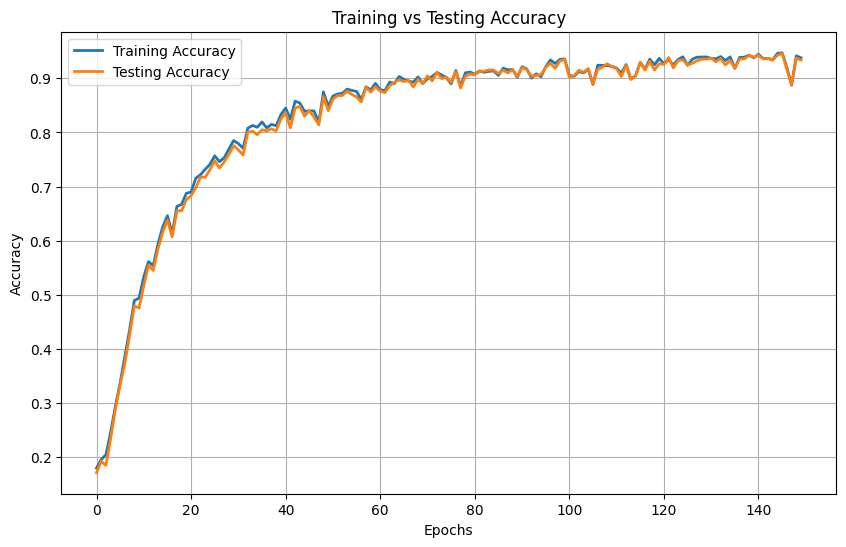

In [ ]:
import matplotlib.pyplot as plt


plt.figure(figsize=(10,6))
plt.plot(train_acc_list, label="Training Accuracy", linewidth=2)
plt.plot(test_acc_list, label="Testing Accuracy", linewidth=2)
plt.title("Training vs Testing Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True)
plt.show()




In [ ]:
# Final evaluation after training completes
model.eval()
test_acc = test(test_loader)
print("Final Test Accuracy:", test_acc)

Final Test Accuracy: 0.9338095238095238


In [ ]:
def predict_from_text(symptom_text):
    user_symptoms = [s.strip().lower() for s in symptom_text.split(",")]

    matched_symptoms = []
    for s in all_symptoms:
        for u in user_symptoms:
            if s.lower() == u:
                matched_symptoms.append(s)

    if len(matched_symptoms) == 0:
        return "No known symptoms detected"

    temp_graph = nx.Graph()
    temp_graph.add_node("patient_case", node_type="patient")

    for s in matched_symptoms:
        temp_graph.add_node(s, node_type="symptom")
        temp_graph.add_edge("patient_case", s)

    pyg_graph = nx_to_pyg(temp_graph, 0)
    pyg_graph = pyg_graph.to(device)

    model.eval()
    with torch.no_grad():
        out = model(pyg_graph)
        pred = out.argmax(dim=1).item()

    return inv_label_map[pred]

In [ ]:
#Demostrating the Predection
sample = test_data[0]
out = model(sample)
pred = out.argmax(dim=1).item()

print("Predicted Disease:", inv_label_map[pred])
print("Actual Disease:", inv_label_map[sample.y.item()])

# User input prediction with updated model
user_input = input("Enter symptoms separated by commas: ")

prediction = predict_from_text(user_input)
print("Predicted Disease:", prediction)


Predicted Disease: Pittaja Vidradhi
Actual Disease: Pittaja Vidradhi
Enter symptoms separated by commas: pain in flanks, pain in waist and back, flatulence, constipation, variable abdominal size, pain in abdomen
Predicted Disease: Vataja Udara


In [ ]:
#User input#
user_input = input("Enter symptoms separated by commas: ")

prediction = predict_from_text(user_input)
print("Predicted Disease:", prediction)


Enter symptoms separated by commas: pain in flanks, pain in waist and back, flatulence, constipation, variable abdominal size, pain in abdomen
Predicted Disease: Vataja Udara


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_recall_curve, average_precision_score
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

In [ ]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import precision_recall_curve, average_precision_score
import numpy as np
import torch

model.eval()

all_probs = []
all_labels = []

with torch.no_grad():
    for data in test_loader:
        data = data.to(device)

        out = model(data)
        probs = torch.softmax(out, dim=1)

        all_probs.append(probs.cpu().numpy())
        all_labels.append(data.y.cpu().numpy())

# Convert to numpy arrays
all_probs = np.vstack(all_probs)
all_labels = np.concatenate(all_labels)

# Binarize labels for multi-class
num_classes = all_probs.shape[1]
all_labels_bin = label_binarize(all_labels, classes=np.arange(num_classes))

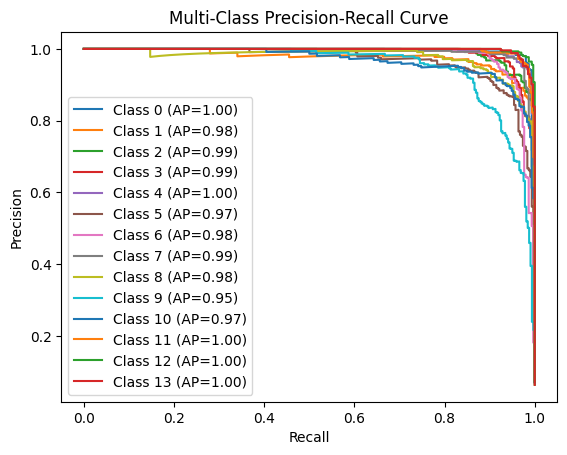

In [ ]:
import matplotlib.pyplot as plt

plt.figure()

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(
        all_labels_bin[:, i], all_probs[:, i]
    )
    avg_precision = average_precision_score(
        all_labels_bin[:, i], all_probs[:, i]
    )

    plt.plot(recall, precision, label=f"Class {i} (AP={avg_precision:.2f})")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Multi-Class Precision-Recall Curve")
plt.legend()

plt.show()


#AP is the PR‑AUC (area under the precision–recall curve).

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score

for i in range(num_classes):
    precision, recall, _ = precision_recall_curve(all_labels_bin[:, i], all_probs[:, i])
    pr_auc = average_precision_score(all_labels_bin[:, i], all_probs[:, i])
    print(f"Class {i} PR-AUC (Average Precision): {pr_auc:.4f}")


Class 0 PR-AUC (Average Precision): 0.9958
Class 1 PR-AUC (Average Precision): 0.9778
Class 2 PR-AUC (Average Precision): 0.9897
Class 3 PR-AUC (Average Precision): 0.9899
Class 4 PR-AUC (Average Precision): 0.9951
Class 5 PR-AUC (Average Precision): 0.9674
Class 6 PR-AUC (Average Precision): 0.9804
Class 7 PR-AUC (Average Precision): 0.9932
Class 8 PR-AUC (Average Precision): 0.9761
Class 9 PR-AUC (Average Precision): 0.9518
Class 10 PR-AUC (Average Precision): 0.9693
Class 11 PR-AUC (Average Precision): 0.9961
Class 12 PR-AUC (Average Precision): 0.9986
Class 13 PR-AUC (Average Precision): 0.9974


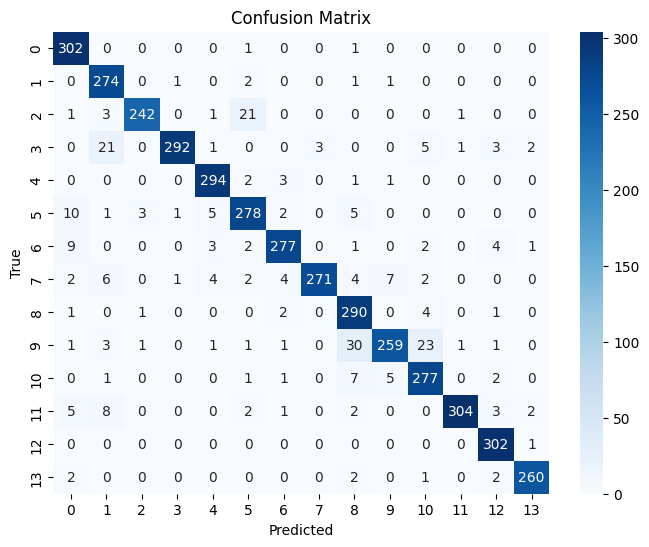

In [ ]:
#Confusion matrix (to see which classes are misclassified into which other classes.)


from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# True labels and predicted labels
y_true = all_labels
y_pred = all_probs.argmax(axis=1)

# Compute confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.title("Confusion Matrix")
plt.show()


In [ ]:
#Specificity (per class)- how well the model avoids false positives for each class.


import numpy as np

specificity = []
for i in range(num_classes):
    tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
    fp = cm[:,i].sum() - cm[i,i]
    specificity.append(tn / (tn + fp))

for i, spec in enumerate(specificity):
    print(f"Class {i} Specificity: {spec:.4f}")





Class 0 Specificity: 0.9920
Class 1 Specificity: 0.9890
Class 2 Specificity: 0.9987
Class 3 Specificity: 0.9992
Class 4 Specificity: 0.9962
Class 5 Specificity: 0.9913
Class 6 Specificity: 0.9964
Class 7 Specificity: 0.9992
Class 8 Specificity: 0.9862
Class 9 Specificity: 0.9964
Class 10 Specificity: 0.9905
Class 11 Specificity: 0.9992
Class 12 Specificity: 0.9959
Class 13 Specificity: 0.9985


In [ ]:
#Sensitivity (Recall)
#Measures how well the model catches true positives for each class.

from sklearn.metrics import recall_score

# True labels and predicted labels
y_true = all_labels
y_pred = all_probs.argmax(axis=1)

# Per-class recall (sensitivity)
recall_per_class = recall_score(y_true, y_pred, average=None)

for i, r in enumerate(recall_per_class):
    print(f"Class {i} Recall (Sensitivity): {r:.4f}")



Class 0 Recall (Sensitivity): 0.9934
Class 1 Recall (Sensitivity): 0.9821
Class 2 Recall (Sensitivity): 0.8996
Class 3 Recall (Sensitivity): 0.8902
Class 4 Recall (Sensitivity): 0.9767
Class 5 Recall (Sensitivity): 0.9115
Class 6 Recall (Sensitivity): 0.9264
Class 7 Recall (Sensitivity): 0.8944
Class 8 Recall (Sensitivity): 0.9699
Class 9 Recall (Sensitivity): 0.8043
Class 10 Recall (Sensitivity): 0.9422
Class 11 Recall (Sensitivity): 0.9297
Class 12 Recall (Sensitivity): 0.9967
Class 13 Recall (Sensitivity): 0.9738


In [ ]:
#Precision
#Measures how many of the predicted positives for a class are actually correct.


from sklearn.metrics import precision_score

# Per-class precision
precision_per_class = precision_score(y_true, y_pred, average=None)

for i, p in enumerate(precision_per_class):
    print(f"Class {i} Precision: {p:.4f}")



Class 0 Precision: 0.9069
Class 1 Precision: 0.8644
Class 2 Precision: 0.9798
Class 3 Precision: 0.9898
Class 4 Precision: 0.9515
Class 5 Precision: 0.8910
Class 6 Precision: 0.9519
Class 7 Precision: 0.9891
Class 8 Precision: 0.8430
Class 9 Precision: 0.9487
Class 10 Precision: 0.8822
Class 11 Precision: 0.9902
Class 12 Precision: 0.9497
Class 13 Precision: 0.9774


In [ ]:
#F1 SCORE

from sklearn.metrics import f1_score

# Per-class F1 score
f1_per_class = f1_score(y_true, y_pred, average=None)

for i, f in enumerate(f1_per_class):
    print(f"Class {i} F1-Score: {f:.4f}")


Class 0 F1-Score: 0.9482
Class 1 F1-Score: 0.9195
Class 2 F1-Score: 0.9380
Class 3 F1-Score: 0.9374
Class 4 F1-Score: 0.9639
Class 5 F1-Score: 0.9011
Class 6 F1-Score: 0.9390
Class 7 F1-Score: 0.9393
Class 8 F1-Score: 0.9020
Class 9 F1-Score: 0.8706
Class 10 F1-Score: 0.9112
Class 11 F1-Score: 0.9590
Class 12 F1-Score: 0.9726
Class 13 F1-Score: 0.9756


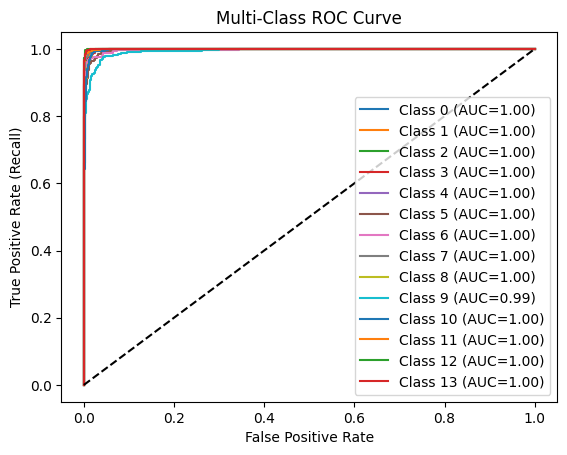

In [ ]:
#ROC Curve + AUC (per class)

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Binarize labels
from sklearn.preprocessing import label_binarize
num_classes = all_probs.shape[1]
y_true_bin = label_binarize(all_labels, classes=np.arange(num_classes))

plt.figure()

for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_true_bin[:, i], all_probs[:, i])
    auc_score = roc_auc_score(y_true_bin[:, i], all_probs[:, i])
    plt.plot(fpr, tpr, label=f"Class {i} (AUC={auc_score:.2f})")

plt.plot([0,1],[0,1],'k--')  # diagonal line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("Multi-Class ROC Curve")
plt.legend()
plt.show()


In [ ]:
#1. ROC‑AUC (per class)
#This uses the Receiver Operating Characteristic (ROC) curve.


from sklearn.metrics import roc_auc_score

# y_true = integer labels
# all_probs = predicted probabilities (num_samples x num_classes)

# Binarize labels (one-hot)
from sklearn.preprocessing import label_binarize
num_classes = all_probs.shape[1]
y_true_bin = label_binarize(all_labels, classes=np.arange(num_classes))

# Per-class AUC
auc_per_class = roc_auc_score(y_true_bin, all_probs, average=None)

for i, auc in enumerate(auc_per_class):
    print(f"Class {i} ROC-AUC: {auc:.4f}")


Class 0 ROC-AUC: 0.9996
Class 1 ROC-AUC: 0.9987
Class 2 ROC-AUC: 0.9993
Class 3 ROC-AUC: 0.9990
Class 4 ROC-AUC: 0.9996
Class 5 ROC-AUC: 0.9970
Class 6 ROC-AUC: 0.9971
Class 7 ROC-AUC: 0.9994
Class 8 ROC-AUC: 0.9983
Class 9 ROC-AUC: 0.9936
Class 10 ROC-AUC: 0.9977
Class 11 ROC-AUC: 0.9996
Class 12 ROC-AUC: 0.9999
Class 13 ROC-AUC: 0.9998


**METRICS**

In [ ]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, average_precision_score
from sklearn.preprocessing import label_binarize

# True labels and predicted labels
y_true = all_labels
y_pred = all_probs.argmax(axis=1)

# Binarize labels for multi-class metrics
num_classes = all_probs.shape[1]
y_true_bin = label_binarize(y_true, classes=np.arange(num_classes))

# Compute metrics
precision = precision_score(y_true, y_pred, average=None)
recall = recall_score(y_true, y_pred, average=None)
f1 = f1_score(y_true, y_pred, average=None)

# Specificity from confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_true, y_pred)
specificity = []
for i in range(num_classes):
    tn = cm.sum() - (cm[i,:].sum() + cm[:,i].sum() - cm[i,i])
    fp = cm[:,i].sum() - cm[i,i]
    specificity.append(tn / (tn + fp))

# ROC-AUC per class
roc_auc = roc_auc_score(y_true_bin, all_probs, average=None)

# PR-AUC (Average Precision) per class
pr_auc = []
for i in range(num_classes):
    ap = average_precision_score(y_true_bin[:, i], all_probs[:, i])
    pr_auc.append(ap)

# Combine into DataFrame
metrics_df = pd.DataFrame({
    "Class": np.arange(num_classes),
    "Precision": precision,
    "Recall (Sensitivity)": recall,
    "Specificity": specificity,
    "F1-Score": f1,
    "ROC-AUC": roc_auc,
    "PR-AUC": pr_auc
})

print(metrics_df.round(4))


    Class  Precision  Recall (Sensitivity)  Specificity  F1-Score  ROC-AUC  \
0       0     0.9069                0.9934       0.9920    0.9482   0.9996   
1       1     0.8644                0.9821       0.9890    0.9195   0.9987   
2       2     0.9798                0.8996       0.9987    0.9380   0.9993   
3       3     0.9898                0.8902       0.9992    0.9374   0.9990   
4       4     0.9515                0.9767       0.9962    0.9639   0.9996   
5       5     0.8910                0.9115       0.9913    0.9011   0.9970   
6       6     0.9519                0.9264       0.9964    0.9390   0.9971   
7       7     0.9891                0.8944       0.9992    0.9393   0.9994   
8       8     0.8430                0.9699       0.9862    0.9020   0.9983   
9       9     0.9487                0.8043       0.9964    0.8706   0.9936   
10     10     0.8822                0.9422       0.9905    0.9112   0.9977   
11     11     0.9902                0.9297       0.9992    0.959

In [ ]:
styled_df = metrics_df.style \
    .set_table_styles([{'selector': 'th',
                        'props': [('font-weight', 'bold'),
                                  ('background-color', '#f0f0f0')]}]) \
    .format("{:.3f}", subset=["Precision","Recall (Sensitivity)",
                              "Specificity","F1-Score","ROC-AUC","PR-AUC"]) \
    .set_caption("Per-Class Evaluation Metrics")
styled_df


,Class,Precision,Recall (Sensitivity),Specificity,F1-Score,ROC-AUC,PR-AUC
0,0,0.907,0.993,0.992,0.948,1.000,0.996
1,1,0.864,0.982,0.989,0.919,0.999,0.978
2,2,0.980,0.900,0.999,0.938,0.999,0.990
3,3,0.990,0.890,0.999,0.937,0.999,0.990
4,4,0.951,0.977,0.996,0.964,1.000,0.995
5,5,0.891,0.911,0.991,0.901,0.997,0.967
6,6,0.952,0.926,0.996,0.939,0.997,0.980
7,7,0.989,0.894,0.999,0.939,0.999,0.993
8,8,0.843,0.970,0.986,0.902,0.998,0.976
9,9,0.949,0.804,0.996,0.871,0.994,0.952


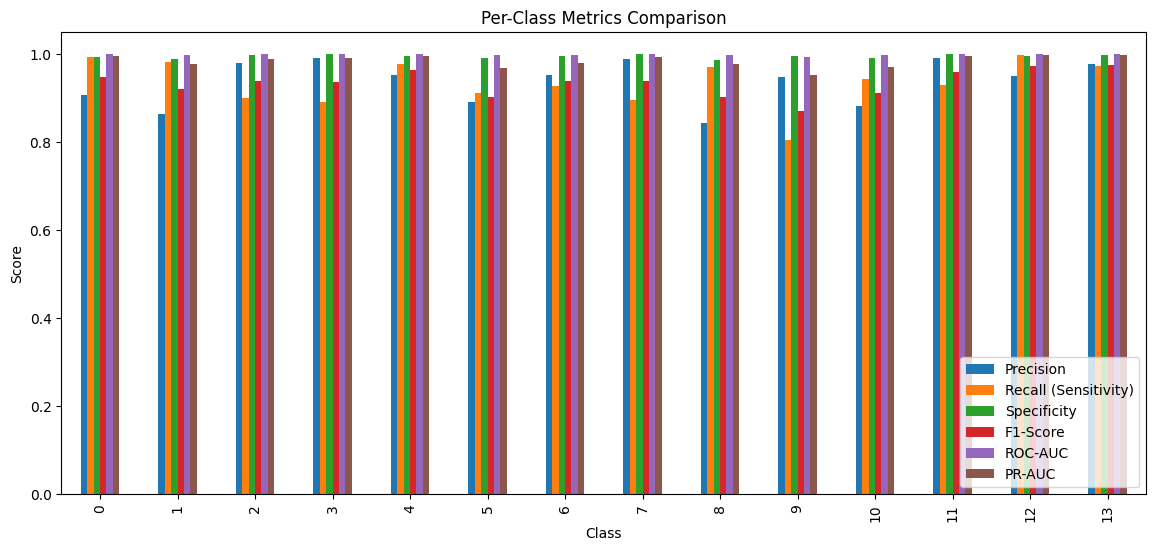

In [ ]:
#Grouped Bar Chart
import matplotlib.pyplot as plt

metrics_to_plot = ["Precision", "Recall (Sensitivity)", "Specificity", "F1-Score", "ROC-AUC", "PR-AUC"]

metrics_df.set_index("Class")[metrics_to_plot].plot(kind="bar", figsize=(14,6))
plt.title("Per-Class Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.legend(loc="lower right")
plt.show()
